<a href="https://colab.research.google.com/github/Najla-Nuricia/PemMes_244107020091_Najla/blob/main/JS05/JS05_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
	import numpy as np
	from sklearn.datasets import make_classification

	# Membuat data dummy
	# Hasil dari make_classification berupa data fitur X dan label y
	# Label y akan berupa data yang sudah di encode (angka)
	X,y = make_classification(n_samples=30, n_features=2, n_classes=2, n_informative=2, n_redundant=0, n_repeated=0, shuffle=False)

	# Secara defalt, make_classfication menghasilkan nilai float
	# Kita perlu merubah dalam bentuk diskrit

	# Absolutekan nilai
	X = np.absolute(X)

	# Bulatkan nilai ke 2 angka dibelakang koma
	# Kalikan dengan 100 supaya tidak ada lagi koma
	X = np.round(X, 2) * 100

	# Ubah ke dalam bentuk integer
	X = X.astype(int)

	# Cek Hasil
	print(X)
	print(y)

[[ 48  30]
 [104 114]
 [100  88]
 [112 150]
 [ 46   4]
 [168 247]
 [ 71  77]
 [ 92  84]
 [127  39]
 [212  50]
 [125  65]
 [163  15]
 [ 43 206]
 [173  72]
 [110 195]
 [147  92]
 [ 75  67]
 [ 32   0]
 [166 149]
 [121  90]
 [326 313]
 [ 36  44]
 [ 30  68]
 [219 215]
 [137  96]
 [162  68]
 [ 28  85]
 [ 62  72]
 [102 140]
 [257 181]]
[0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 1 1 1 1 1 1 1]


In [2]:
import pandas as pd

# Reshape label y menjadi 2D
# Hal ini dilakukan karena kita akan menggabungkannya dengan data fitur X
y_new = y.reshape(len(y), 1)

# Gabungkan fitur X dan label y dalam data array
data = np.concatenate((X, y_new), axis=1)

# Definisikan nama kolom
nama_kolom = ['Fitur 1', 'Fitur 2', 'Label']

# Buat Data Frame
df = pd.DataFrame(data, columns=nama_kolom)

# Cek Data Frame
df.head()

,Fitur 1,Fitur 2,Label
0,48,30,0
1,104,114,0
2,100,88,0
3,112,150,0
4,46,4,0


In [3]:
	# Definisikan nama label
	labels = {
	    1 : 'Kelas A',
	    0 : 'Kelas B'
	}

	# Copy Data Frame untuk menyimpan Data Frame baru
	# dengan label yang mudah untuk dibaca
	df_label = df.copy()

	# Ubah label dengan fungsi mapping dari Pandas
	# pada Data Frame df_label
	df_label['Label'] = df_label['Label'].map(labels)

	# Cek Data Frame df_label
	df_label.head()

,Fitur 1,Fitur 2,Label
0,48,30,Kelas B
1,104,114,Kelas B
2,100,88,Kelas B
3,112,150,Kelas B
4,46,4,Kelas B


/tmp/ipykernel_1459/1912510248.py:11: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  class_a = gb.get_group('Kelas A')
/tmp/ipykernel_1459/1912510248.py:12: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  class_b = gb.get_group('Kelas B')


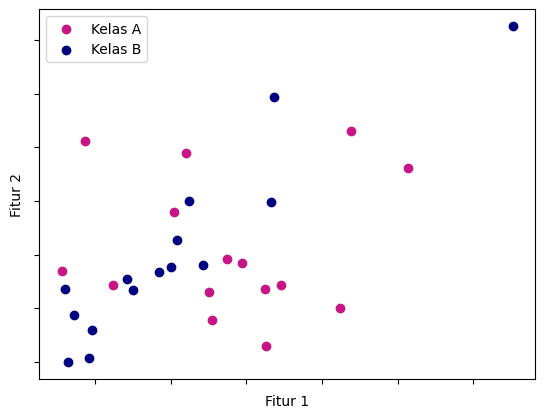

In [4]:
	import matplotlib.pyplot as plt

	# Definisikan warna untuk setiap kelas
	colors = {
	    'class_a': 'MediumVioletRed',
	    'class_b': 'Navy'
	}

	# Kelompokkan label berdasarkan nama kelas
	gb = df_label.groupby(['Label'])
	class_a = gb.get_group('Kelas A')
	class_b = gb.get_group('Kelas B')

	# Plot
	plt.scatter(x=class_a['Fitur 1'], y=class_a['Fitur 2'], c=colors['class_a'])
	plt.scatter(x=class_b['Fitur 1'], y=class_b['Fitur 2'], c=colors['class_b'])
	plt.xlabel('Fitur 1')
	plt.ylabel('Fitur 2')
	plt.legend(['Kelas A', 'Kelas B'])
	plt.gca().axes.xaxis.set_ticklabels([])
	plt.gca().axes.yaxis.set_ticklabels([])
	plt.show()

In [5]:
	from sklearn.naive_bayes import MultinomialNB # class untuk model MultinomialNB
	from sklearn.model_selection import train_test_split
	from sklearn.metrics import accuracy_score # evaluasi model berdasarkan akurasi

	# Inisiasi obyek MultinomialNB
	mnb = MultinomialNB()

	# Kita dapat langsung menggunakan fitur X dan label y
	# hasil dari proses pembuatan data dummy

	# Split data training dan testing
	X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=30)

	# Fit model
	# Label y harus dalam bentuk 1D atau (n_samples,)
	mnb.fit(X_train, y_train)

	# Prediksi dengan data training
	y_train_pred = mnb.predict(X_train)

	# Evaluasi akurasi training
	acc_train = accuracy_score(y_train, y_train_pred)

	# Prediksi test data
	y_test_pred = mnb.predict(X_test)

	# Evaluasi model dengan metric akurasi
	acc_test = accuracy_score(y_test, y_test_pred)

	# Print hasil evaluasi
	print(f'Hasil akurasi data train: {acc_train}')
	print(f'Hasil akurasi data test: {acc_test}')

Hasil akurasi data train: 0.6666666666666666
Hasil akurasi data test: 0.6666666666666666


In [6]:
	from sklearn.naive_bayes import GaussianNB # class untuk model GaussianNB

	# Inisiasi obyek Gaussian
	gnb = GaussianNB()

	# Kita menggunakan split data training dan testing
	# yang sama dengan model multinomial

	# Fit model
	# Label y harus dalam bentu 1D atau (n_samples,)
	gnb.fit(X_train, y_train)

	# Prediksi dengan data training
	y_train_pred_gnb = gnb.predict(X_train)

	# Evaluasi akurasi training
	acc_train_gnb = accuracy_score(y_train, y_train_pred_gnb)

	# Prediksi test data
	y_test_pred_gnb = gnb.predict(X_test)

	# Evaluasi model dengan metric akurasi
	acc_test_gnb = accuracy_score(y_test, y_test_pred_gnb)

	# Print hasil evaluasi
	print(f'Hasil akurasi data train (Gaussian): {acc_train_gnb}')
	print(f'Hasil akurasi data test (Gaussian): {acc_test_gnb}')

Hasil akurasi data train (Gaussian): 0.6190476190476191
Hasil akurasi data test (Gaussian): 0.2222222222222222
